# EBM Filter-Then-Interact

Explainable Boosting Machine amb estrategia filter-then-interact:
1. **Phase 1:** EBM additiu (interactions=0, min_samples_leaf=2) per ranking de features
2. **Phase 2 (Pruning):** Seleccio top-15 features per importancia (elbow method)
3. **Phase 3:** EBM amb interaccions FAST (interactions=10, min_samples_leaf=10) sobre les top-15

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from interpret.glassbox import ExplainableBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Carrega i neteja de dades

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from interpret.glassbox import ExplainableBoostingRegressor
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../../..')
from data_cleaning import get_time_columns, get_lot_number_columns

df = pd.read_csv('../../../data/fractionation_data.csv', low_memory=False)
print(f'Original shape: {df.shape}')

# Drop identifier
if 'A1' in df.columns:
    df = df.drop(columns=['A1'])

# Remove D48 (weight - trivially correlated with yield)
if 'D48' in df.columns:
    df = df.drop(columns=['D48'])

# Remove time and lot columns (no predictive value, temporal leakage)
time_cols = [c for c in get_time_columns() if c in df.columns]
lot_cols = [c for c in get_lot_number_columns() if c in df.columns]
df = df.drop(columns=time_cols + lot_cols, errors='ignore')
print(f'After removing time/lot columns: {df.shape}')

# Remove columns AFTER D49 (post-process measurements)
if 'D49' in df.columns:
    d49_pos = list(df.columns).index('D49')
    post_d49_cols = list(df.columns[d49_pos+1:])
    df = df.drop(columns=post_d49_cols)
    print(f'After removing post-D49 columns: {df.shape}')

# Filter to 2024+ data (process change, per article section 4.1)
if 'B1' in df.columns:
    df['B1_dt'] = pd.to_datetime(df['B1'], errors='coerce')
    df = df[df['B1_dt'] >= '2024-01-01'].copy()
    df = df.drop(columns=['B1_dt', 'B1'], errors='ignore')
    print(f'After filtering 2024+: {df.shape}')

# Identify categorical columns
manual_categorical = ['B10', 'B11', 'B12', 'B13', 'C1', 'C10', 'C17', 'C19',
                      'C31', 'C6', 'D1', 'D11', 'D13', 'D20c', 'D24', 'D25',
                      'D27', 'D29', 'D3', 'D32', 'D34', 'D36b', 'D46']
object_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = sorted(list(set(manual_categorical + object_cols) & set(df.columns)))
print(f'Categorical columns: {len(categorical_cols)}')
print(f'Dataset ready: {df.shape}')


2026-06-04 21:04:12.720 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-06-04 21:04:12.720 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Original shape: (4616, 151)
After removing time/lot columns: (4616, 114)
After removing post-D49 columns: (4616, 101)
Categorical columns: 10
Dataset ready: (4616, 101)


In [3]:
# --- Data Cleaning Pipeline ---
# Work with numeric columns only (categorical handled natively by EBM in app_filter.py)
df_numeric = df.select_dtypes(include=[np.number]).copy()

# Step 1: Remove columns with >35% missing
missing_pct = df_numeric.isnull().sum() / len(df_numeric)
cols_keep = missing_pct[missing_pct <= 0.35].index.tolist()
if 'D49' not in cols_keep:
    cols_keep.append('D49')
df_clean = df_numeric[cols_keep].copy()
print(f'After removing >35% missing: {df_clean.shape}')

# Step 2: Remove low variance (<0.10)
feature_cols = [c for c in df_clean.columns if c != 'D49']
variances = df_clean[feature_cols].var()
low_var_cols = variances[variances < 0.10].index.tolist()
df_clean = df_clean.drop(columns=low_var_cols)
print(f'After removing low variance: {df_clean.shape}')

# Step 3: Remove high correlation (>0.90)
feature_cols = [c for c in df_clean.columns if c != 'D49']
if len(feature_cols) > 1:
    corr_matrix = df_clean[feature_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.90)]
    df_clean = df_clean.drop(columns=high_corr_cols)
print(f'After removing high correlation: {df_clean.shape}')

# Drop rows with any missing values (required for Lasso comparison)
df_clean = df_clean.dropna().copy()

# Setup features and target
feature_cols = [c for c in df_clean.columns if c != 'D49']
X = df_clean[feature_cols].copy()
y = df_clean['D49'].copy()
print(f'Final dataset: {X.shape[0]} samples, {X.shape[1]} features (numeric only)')
print(f'Note: Full pipeline in app_filter.py also includes categorical variables for higher accuracy')


After removing >35% missing: (4616, 75)
After removing low variance: (4616, 66)
After removing high correlation: (4616, 50)
Final dataset: 2655 samples, 49 features (numeric only)
Note: Full pipeline in app_filter.py also includes categorical variables for higher accuracy


In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1991, 49), Test: (664, 49)


## 2. Phase 1: EBM Additive - Feature Ranking (interactions=0, min_samples_leaf=2)

In [5]:
# Phase 1: Additive EBM for feature ranking
# min_samples_leaf=2 maximizes sensitivity to detect all relevant signals
ebm_phase1 = ExplainableBoostingRegressor(
    max_bins=256,
    max_rounds=1000,
    learning_rate=0.05,
    min_samples_leaf=2,       # Phase 1: sensitive leaf for signal detection
    interactions=0,           # Purely additive - no interactions
    random_state=42,
    n_jobs=1
)

ebm_phase1.fit(X_train, y_train)
y_pred_phase1 = ebm_phase1.predict(X_test)

mae_p1 = mean_absolute_error(y_test, y_pred_phase1)
rmse_p1 = np.sqrt(mean_squared_error(y_test, y_pred_phase1))
r2_p1 = r2_score(y_test, y_pred_phase1)

print('=== Phase 1: EBM Additive (interactions=0, min_samples_leaf=2) ===')
print(f'MAE:  {mae_p1:.4f}')
print(f'RMSE: {rmse_p1:.4f}')
print(f'R2:   {r2_p1:.4f}')

=== Phase 1: EBM Additive (interactions=0, min_samples_leaf=2) ===
MAE:  0.8198
RMSE: 1.0609
R2:   0.5890


## 3. Phase 2: Feature Selection - Top 15 by Importance (Elbow Method)

Top 20 features by importance (Phase 1):
   Feature  Importance
0      C33    0.313439
1      C40    0.255124
2      D40    0.240868
3      D15    0.227268
4      B24    0.225657
5      D36    0.207367
6      D26    0.191364
7      D47    0.188745
8      D28    0.139656
9      D38    0.125350
10      D1    0.109582
11     B27    0.094862
12     D19    0.094642
13     C38    0.091867
14      D6    0.088611
15     D12    0.084384
16     B28    0.084098
17      C8    0.080504
18     C36    0.080169
19     C29    0.075372


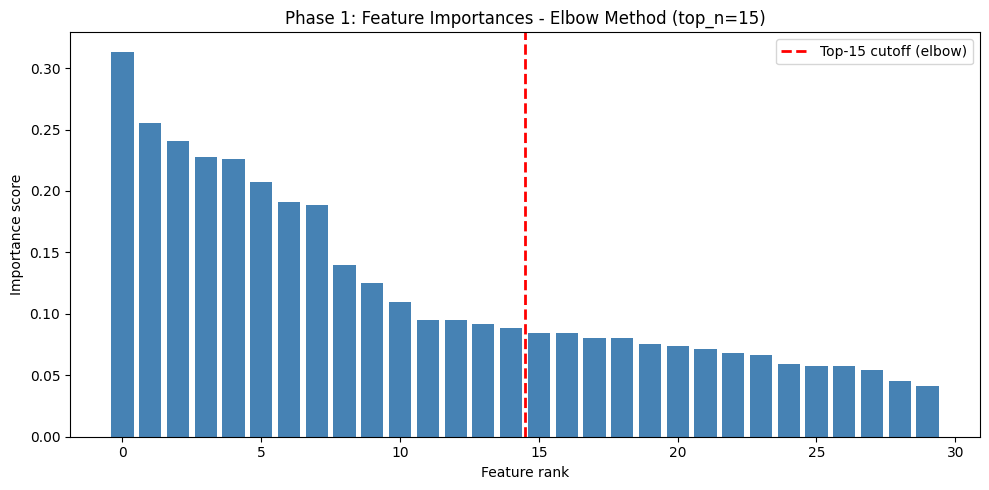

In [6]:
# Extract feature importances from Phase 1
global_exp = ebm_phase1.explain_global(name='Phase 1 - Feature Ranking')
global_data = global_exp.data()

importance_df = pd.DataFrame({
    'Feature': global_data['names'],
    'Importance': global_data['scores']
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 20 features by importance (Phase 1):')
print(importance_df.head(20).to_string(index=True))

# Visualize with elbow cutoff
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(min(30, len(importance_df))), importance_df['Importance'].head(30), color='steelblue')
ax.axvline(x=14.5, color='red', linestyle='--', linewidth=2, label='Top-15 cutoff (elbow)')
ax.set_xlabel('Feature rank')
ax.set_ylabel('Importance score')
ax.set_title('Phase 1: Feature Importances - Elbow Method (top_n=15)')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Select top-15 features (Phase 2: Pruning)
top_n = 15
top_15_features = importance_df.head(top_n)['Feature'].tolist()
print(f'\nSelected top-{top_n} features:')
for i, feat in enumerate(top_15_features, 1):
    imp_val = importance_df.loc[importance_df['Feature'] == feat, 'Importance'].values[0]
    print(f'  {i:2d}. {feat:<10} (importance: {imp_val:.4f})')

X_train_top = X_train[top_15_features]
X_test_top = X_test[top_15_features]


Selected top-15 features:
   1. C33        (importance: 0.3134)
   2. C40        (importance: 0.2551)
   3. D40        (importance: 0.2409)
   4. D15        (importance: 0.2273)
   5. B24        (importance: 0.2257)
   6. D36        (importance: 0.2074)
   7. D26        (importance: 0.1914)
   8. D47        (importance: 0.1887)
   9. D28        (importance: 0.1397)
  10. D38        (importance: 0.1253)
  11. D1         (importance: 0.1096)
  12. B27        (importance: 0.0949)
  13. D19        (importance: 0.0946)
  14. C38        (importance: 0.0919)
  15. D6         (importance: 0.0886)


## 4. Phase 3: EBM with FAST Interactions (interactions=10, min_samples_leaf=10)

In [8]:
# Phase 3: EBM with FAST algorithm interactions on top-15 features
# min_samples_leaf=10 ensures robust, generalizable shape functions
ebm_phase3 = ExplainableBoostingRegressor(
    max_bins=256,
    max_rounds=1000,
    learning_rate=0.05,
    min_samples_leaf=10,      # Phase 3: robust leaf for generalization
    interactions=10,          # FAST algorithm detects top-10 interactions
    random_state=42,
    n_jobs=1
)

ebm_phase3.fit(X_train_top, y_train)
y_pred_ebm = ebm_phase3.predict(X_test_top)

mae_ebm = mean_absolute_error(y_test, y_pred_ebm)
rmse_ebm = np.sqrt(mean_squared_error(y_test, y_pred_ebm))
r2_ebm = r2_score(y_test, y_pred_ebm)

print('=== Phase 3: EBM Robust (interactions=10, min_samples_leaf=10, top-15) ===')
print(f'MAE:  {mae_ebm:.4f}')
print(f'RMSE: {rmse_ebm:.4f}')
print(f'R2:   {r2_ebm:.4f}')

=== Phase 3: EBM Robust (interactions=10, min_samples_leaf=10, top-15) ===
MAE:  0.8182
RMSE: 1.0502
R2:   0.5973


## 5. 5-Fold Cross-Validation (Phase 3 Configuration)

In [9]:
# 5-fold CV on Phase 3 EBM configuration
X_top = X[top_15_features].copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae = []
cv_rmse = []
cv_r2 = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_top), 1):
    X_tr, X_val = X_top.iloc[train_idx], X_top.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    ebm_cv = ExplainableBoostingRegressor(
        max_bins=256,
        max_rounds=1000,
        learning_rate=0.05,
        min_samples_leaf=10,
        interactions=10,
        random_state=42,
        n_jobs=1
    )
    ebm_cv.fit(X_tr, y_tr)
    y_pred_cv = ebm_cv.predict(X_val)
    
    cv_mae.append(mean_absolute_error(y_val, y_pred_cv))
    cv_rmse.append(np.sqrt(mean_squared_error(y_val, y_pred_cv)))
    cv_r2.append(r2_score(y_val, y_pred_cv))
    print(f'Fold {fold}: MAE={cv_mae[-1]:.4f}, RMSE={cv_rmse[-1]:.4f}, R2={cv_r2[-1]:.4f}')

print(f'\n=== 5-Fold CV Summary ===')
print(f'MAE:  {np.mean(cv_mae):.4f} +/- {np.std(cv_mae):.4f}')
print(f'RMSE: {np.mean(cv_rmse):.4f} +/- {np.std(cv_rmse):.4f}')
print(f'R2:   {np.mean(cv_r2):.4f} +/- {np.std(cv_r2):.4f}')

Fold 1: MAE=0.8230, RMSE=1.0473, R2=0.5969


Fold 2: MAE=0.8191, RMSE=1.0289, R2=0.6264


Fold 3: MAE=0.8518, RMSE=1.0809, R2=0.5855


Fold 4: MAE=0.8524, RMSE=1.0815, R2=0.5928


Fold 5: MAE=0.8548, RMSE=1.0969, R2=0.6178

=== 5-Fold CV Summary ===
MAE:  0.8402 +/- 0.0157
RMSE: 1.0671 +/- 0.0250
R2:   0.6039 +/- 0.0156


## 6. Global Feature Importances (Phase 3 Model)

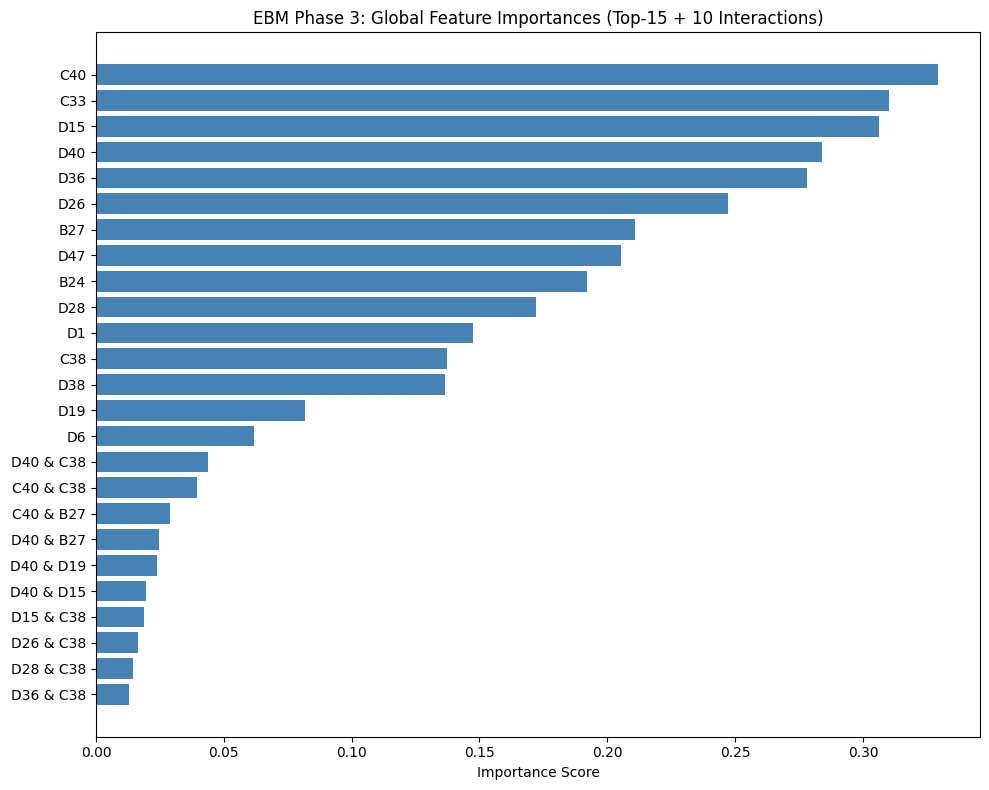

  Feature  Importance
      C40    0.329321
      C33    0.310289
      D15    0.306119
      D40    0.283918
      D36    0.277967
      D26    0.247341
      B27    0.210654
      D47    0.205389
      B24    0.192014
      D28    0.172052
       D1    0.147526
      C38    0.137439
      D38    0.136650
      D19    0.081730
       D6    0.061827
D40 & C38    0.043932
C40 & C38    0.039697
C40 & B27    0.029083
D40 & B27    0.024517
D40 & D19    0.023803
D40 & D15    0.019700
D15 & C38    0.018650
D26 & C38    0.016504
D28 & C38    0.014548
D36 & C38    0.013103


In [10]:
# Global explanation from Phase 3 model
global_exp_final = ebm_phase3.explain_global(name='EBM Phase 3 (Robust)')
global_data_final = global_exp_final.data()

imp_final = pd.DataFrame({
    'Feature': global_data_final['names'],
    'Importance': global_data_final['scores']
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
imp_plot = imp_final.sort_values('Importance', ascending=True)
ax.barh(imp_plot['Feature'], imp_plot['Importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('EBM Phase 3: Global Feature Importances (Top-15 + 10 Interactions)')
plt.tight_layout()
plt.show()

print(imp_final.to_string(index=False))

## 7. Shape Functions (Top 3 Features)

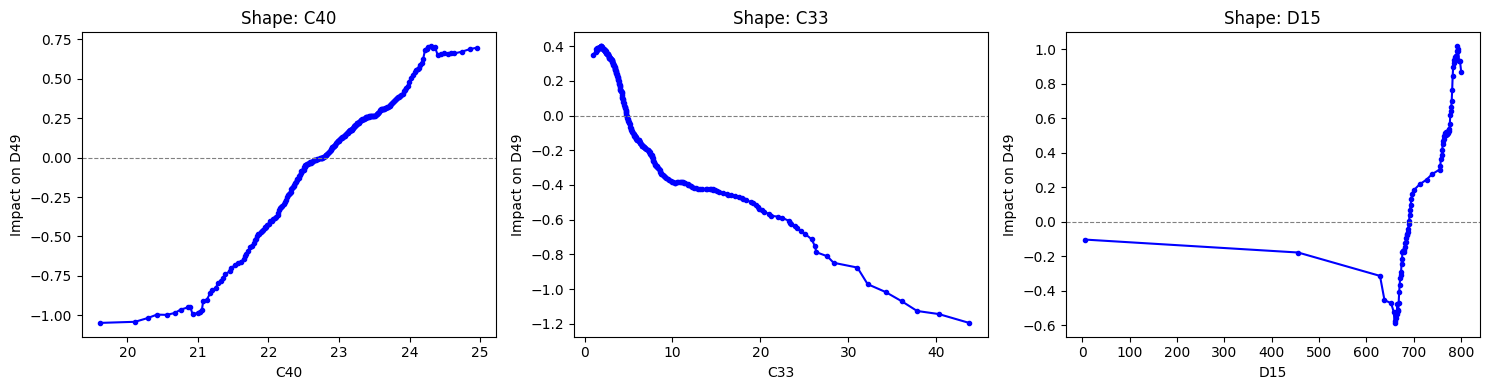

In [11]:
# Plot shape functions for top 3 features
top_3 = imp_final.head(3)['Feature'].tolist()
feature_names_all = global_data_final['names']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat_name in enumerate(top_3):
    if feat_name in feature_names_all:
        feat_idx = list(feature_names_all).index(feat_name)
        feat_data = global_exp_final.data(feat_idx)
        
        x_vals = feat_data['names']
        y_vals = feat_data['scores']
        
        # Ensure same length
        min_len = min(len(x_vals), len(y_vals))
        x_vals = x_vals[:min_len]
        y_vals = y_vals[:min_len]
        
        # Try to convert to numeric for line plot
        x_numeric = pd.to_numeric(pd.Series(x_vals), errors='coerce')
        
        if x_numeric.notna().all() and len(x_numeric) > 1:
            sort_idx = x_numeric.argsort()
            axes[i].plot(x_numeric.iloc[sort_idx], np.array(y_vals)[sort_idx], 'b-o', markersize=3)
        else:
            axes[i].bar(range(len(y_vals)), y_vals)
            if len(x_vals) <= 20:
                axes[i].set_xticks(range(len(x_vals)))
                axes[i].set_xticklabels(x_vals, rotation=45, ha='right', fontsize=7)
        
        axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
        axes[i].set_title(f'Shape: {feat_name}')
        axes[i].set_xlabel(feat_name)
        axes[i].set_ylabel('Impact on D49')

plt.tight_layout()
plt.show()

## 8. Comparacio amb Lasso Baseline

In [12]:
# Handle NaN for Lasso (EBM handles NaN natively, Lasso does not)
X_for_lasso = X.dropna()
y_for_lasso = y[X_for_lasso.index]
print(f'Lasso dataset (after dropping NaN rows): {X_for_lasso.shape}')

# Lasso baseline (alpha=0.01)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

n_nonzero = np.sum(lasso.coef_ != 0)
print(f'Lasso non-zero coefficients: {n_nonzero} / {len(lasso.coef_)}')

Lasso dataset (after dropping NaN rows): (2655, 49)
Lasso non-zero coefficients: 40 / 49


In [13]:
# ============================================================
# SUMMARY COMPARISON TABLE
# ============================================================
print('=' * 72)
print('MODEL COMPARISON SUMMARY')
print('=' * 72)
print(f'{"Model":<45} {"MAE":<10} {"RMSE":<10} {"R2":<10}')
print('-' * 72)
print(f'{"Lasso (alpha=0.01, all features)":<45} {mae_lasso:<10.4f} {rmse_lasso:<10.4f} {r2_lasso:<10.4f}')
print(f'{"EBM Phase 1 (additive, leaf=2, all feat.)":<45} {mae_p1:<10.4f} {rmse_p1:<10.4f} {r2_p1:<10.4f}')
print(f'{"EBM Phase 3 (interact=10, leaf=10, top-15)":<45} {mae_ebm:<10.4f} {rmse_ebm:<10.4f} {r2_ebm:<10.4f}')
print('=' * 72)

print(f'\n--- 5-Fold CV (Phase 3 configuration) ---')
print(f'  MAE:  {np.mean(cv_mae):.4f} +/- {np.std(cv_mae):.4f}')
print(f'  RMSE: {np.mean(cv_rmse):.4f} +/- {np.std(cv_rmse):.4f}')
print(f'  R2:   {np.mean(cv_r2):.4f} +/- {np.std(cv_r2):.4f}')

# Improvement metrics
if mae_lasso > 0:
    mae_improv = ((mae_lasso - mae_ebm) / mae_lasso) * 100
    print(f'\n--- EBM Phase 3 vs Lasso ---')
    print(f'  MAE reduction: {mae_improv:.1f}%')
if r2_lasso > 0:
    r2_improv = ((r2_ebm - r2_lasso) / r2_lasso) * 100
    print(f'  R2 improvement: {r2_improv:.1f}%')
else:
    print(f'  Lasso R2 = {r2_lasso:.4f} (EBM clearly superior)')

MODEL COMPARISON SUMMARY
Model                                         MAE        RMSE       R2        
------------------------------------------------------------------------
Lasso (alpha=0.01, all features)              0.8664     1.1144     0.5465    
EBM Phase 1 (additive, leaf=2, all feat.)     0.8198     1.0609     0.5890    
EBM Phase 3 (interact=10, leaf=10, top-15)    0.8182     1.0502     0.5973    

--- 5-Fold CV (Phase 3 configuration) ---
  MAE:  0.8402 +/- 0.0157
  RMSE: 1.0671 +/- 0.0250
  R2:   0.6039 +/- 0.0156

--- EBM Phase 3 vs Lasso ---
  MAE reduction: 5.6%
  R2 improvement: 9.3%
